# 8. hét – Bernstein–Vazirani algoritmus és alkalmazása

**Cél**: Megérteni és implementálni a Bernstein–Vazirani algoritmust Qiskittel. Láthatóvá tenni, hogyan old meg egy problémát egyetlen kvantum lekérdezéssel, amit klasszikusan n lekérdezés kell.

In [1]:
# Alap importok
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()

### 1. Kis példa: n = 3, rejtett vektor s = '101' (bináris)

In [ ]:
n = 3
secret_string = '101'   # Rejtett bitvektor (s)

qc = QuantumCircuit(n+1, n)   # n bemeneti qubit + 1 segédqubit + n klasszikus bit

# Inicializálás: minden bemeneti qubit |+⟩ állapotba (Hadamard)
for i in range(n):
    qc.h(i)

# Segédqubit |−⟩ állapotba (X majd H)
qc.x(n)
qc.h(n)

qc.barrier() # Csak vizuális elválasztás – nem befolyásolja az eredményt

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

### 2. Orákulum: U_f |x⟩|y⟩ = |x⟩|y ⊕ s·x⟩
(CNOT-ok ott, ahol s bitje 1)

In [3]:
# Orákulum implementációja
for i in range(n):
    if secret_string[i] == '1':
        qc.cx(i, n)   # ha s_i = 1, akkor CNOT az i-edik qubitről a segédqubitre

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

### 3. Második Hadamard transzformáció + mérés

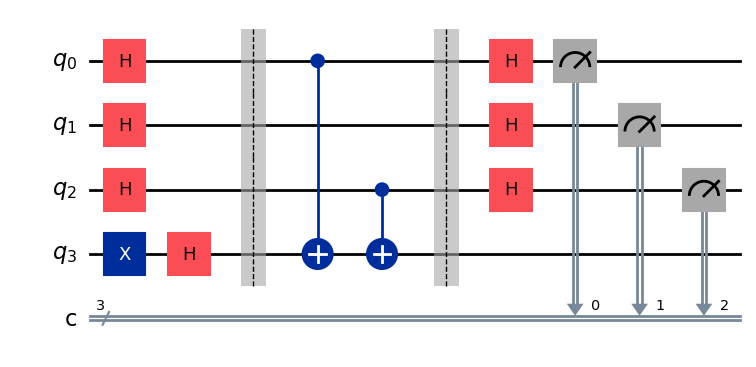

In [4]:
# Hadamard minden bemeneti qubiten (interferencia)
for i in range(n):
    qc.h(i)

# Mérjük a bemeneti qubiteket
qc.measure(range(n), range(n))

display(qc.draw('mpl'))

### 4. Futtatás és eredmény

Mérési eredmények: {'101': 1024}


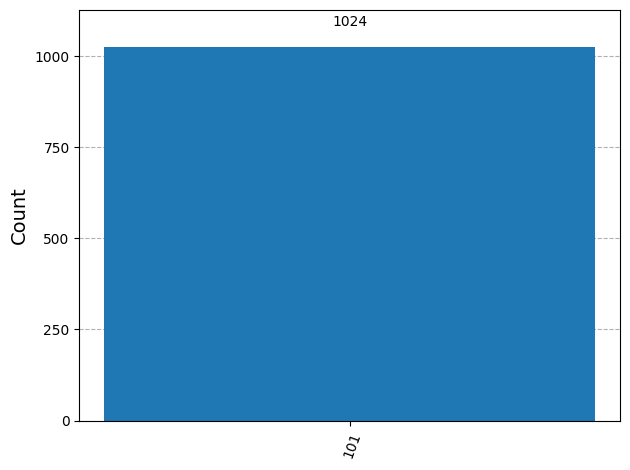

In [ ]:
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Mérési eredmények:", counts)
plot_histogram(counts)

# Várható: a '101' 100%-ban

# 5. Több secret string összehasonlítása (paraméterezés demonstráció)

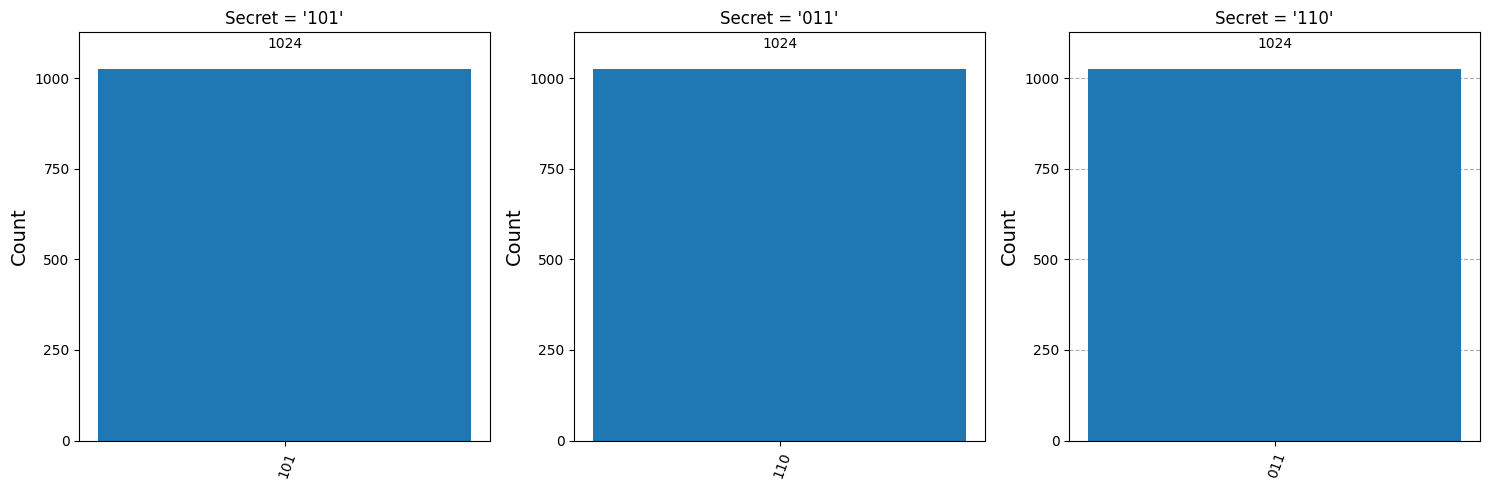

In [ ]:
secrets = ['101', '011', '110']  # 3 érték, rövidre fogva

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, secret in enumerate(secrets):
    qc = QuantumCircuit(n+1, n)  # Új áramkör minden secret-hez!

    # Inicializálás (ugyanaz, mint a példában)
    for j in range(n):
        qc.h(j)

    qc.x(n)
    qc.h(n)
    qc.barrier()

    # Orákulum
    for j in range(n):
        if secret[j] == '1':
            qc.cx(j, n)
            
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    
    job = simulator.run(transpile(qc, simulator), shots=1024)

    counts = job.result().get_counts()

    plot_histogram(counts, ax=axs[i])

    axs[i].set_title(f"Secret = '{secret}'")
    
plt.tight_layout()
plt.show()

Minden secret-hez a megfelelő bitvektort kapjuk vissza – kísérletezzetek többel a projektben!

Megfigyelés: Minden secret string esetén az algoritmus egyetlen futással visszaadja a rejtett vektort (determinisztikus eredmény).
Ez mutatja a kvantum előnyét: klasszikusan n lekérdezés kell, itt elég 1.
Használjátok ezt a projektben több bemenet kipróbálására és összehasonlítására.